In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.metrics import r2_score, mean_squared_error

In [69]:
df = pd.read_csv("saved_files/df_boyas_tiffs_c2x_test.csv")

In [70]:
df.head(2)

,Date,Buoy,Latitude,Longitude,Band_1,Band_2,Band_3,Band_4,Band_5,Band_6,Band_7,Band_8,Band_9,Band_10,Band_11,Band_12,Band_13,Band_14,Band_15,Chl
0,2018-02-20,CTD1,4.187246e+06,695024.711677,0.001484,0.004081,0.011146,0.008187,0.007236,0.002246,0.002191,0.000872,0.001496,0.004132,0.011406,0.008824,0.007310,0.002291,-1.100000e-44,3.243742
1,2018-02-20,CTD2,4.181518e+06,693105.156141,0.001879,0.005718,0.015010,0.005521,0.003285,0.000903,0.000874,0.000346,0.001883,0.005933,0.015199,0.005514,0.003593,0.000874,-1.100000e-44,4.962618


In [71]:
df = df.drop(columns=["Latitude", "Longitude", "Band_8", "Band_9", "Band_10", "Band_11", "Band_12", "Band_13", "Band_14", "Band_15"])
df = df.rename(columns={"Band_1" : "UltraBlue", "Band_2" : "Blue", "Band_3" : "Green", "Band_4" : "Red", "Band_5" : "NIR1", "Band_6" : "NIR2", "Band_7" : "NIR3"})
df['Date'] = pd.to_datetime(df['Date'])
dates = df["Date"].copy()
df = df.drop(columns=["Date"]) 


In [63]:
# Normalizar parece que empeora
# cols = ['UltraBlue', 'Blue', 'Green', 'Red', 'NIR1', 'NIR2', 'NIR3']  
# df[cols] = (df[cols] - df[cols].min()) / (df[cols].max() - df[cols].min())

In [72]:
df.describe()

,UltraBlue,Blue,Green,Red,NIR1,NIR2,NIR3,Chl
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.008578,0.015551,0.025106,0.007548,0.005526,0.001558,0.001514,2.752304
std,0.006249,0.008264,0.011870,0.005390,0.005137,0.001781,0.001758,2.564789
min,0.001028,0.003140,0.006710,0.000840,0.000419,0.000104,0.000095,0.236828
25%,0.004049,0.009413,0.016001,0.004055,0.002499,0.000644,0.000626,0.815628
50%,0.007057,0.015083,0.024040,0.006854,0.004782,0.001306,0.001263,1.800276
75%,0.012026,0.020202,0.030139,0.008754,0.006431,0.001815,0.001765,3.898444
max,0.030226,0.045776,0.073334,0.043624,0.045448,0.016903,0.016772,10.938851


In [73]:
df.head(3)

,Buoy,UltraBlue,Blue,Green,Red,NIR1,NIR2,NIR3,Chl
0,CTD1,0.001484,0.004081,0.011146,0.008187,0.007236,0.002246,0.002191,3.243742
1,CTD2,0.001879,0.005718,0.015010,0.005521,0.003285,0.000903,0.000874,4.962618
2,CTD3,0.002975,0.008844,0.017780,0.003417,0.002103,0.000528,0.000510,3.602579


### 1. De "Análisis multisensor de la variabilidad espacio temporal de diversos parámetros biofísicos en el Mar Menor"

La fórmula que se propone en este artículo es $y = 0.6386 e^{4.7513x}$, donde $y$ es la clorofila y $x$ es la relación de $(Green - Blue)/(Green + Blue)$

In [74]:
def norm_dif(band1, band2):
    index = (band1 - band2)/(band1 + band2 + 1e-8)
    return index

def add_index_green_blue(data):
    df["norm_dif_green_blue"] = norm_dif(data["Green"], data["Blue"])
    df[f"index_green_blue"] = 0.6386*np.exp(4.7513*(norm_dif(data["Green"], data["Blue"])))
add_index_green_blue(df)

def add_index_green_red(data):
    df["norm_dif_green_red"] = norm_dif(data["Green"], data["Red"])
    df[f"index_green_red"] = 0.6386*np.exp(4.7513*(norm_dif(data["Green"], data["Red"])))
add_index_green_red(df)

In [75]:
r2 = r2_score(df["Chl"], df["index_green_blue"])
print('R squared GreenBlue: %.3f' % r2)
r2 = r2_score(df["Chl"], df["index_green_red"])
print('R squared GreenRed: %.3f' % r2)

R squared GreenBlue: 0.148
R squared GreenRed: -13.946


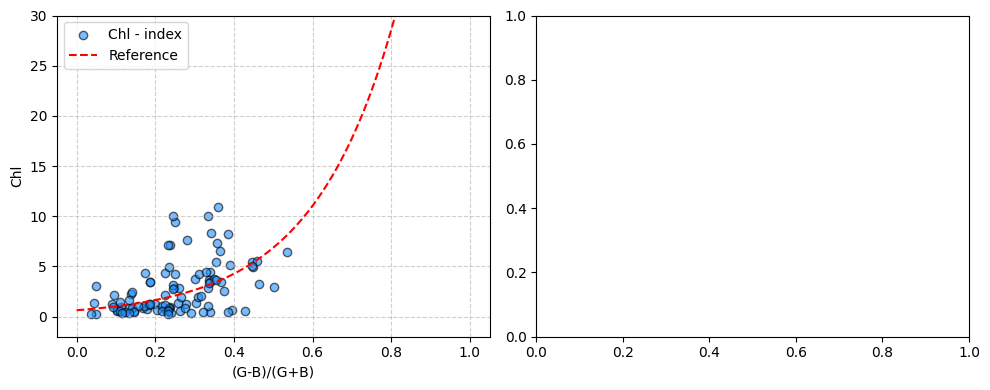

In [76]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# Train plot
axes[0].scatter(df["norm_dif_green_blue"], df["Chl"], color="dodgerblue", alpha=0.6, edgecolor="k", label="Chl - index")
axes[0].plot(np.linspace(0,1, 101), 0.6386*np.exp(4.7513*(np.linspace(0,1, 101))), color="red", linestyle="--", label="Reference")
axes[0].set_xlabel("(G-B)/(G+B)")
axes[0].set_ylabel("Chl")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].set_ylim(-2,30)

# Test plot
# axes[1].scatter(y_test, test_prediction, color="orange", alpha=0.6, edgecolor="k", label="Test prediction")
# axes[1].plot(y_test, y_test, color="red", linestyle="--", label="Reference")
# axes[1].set_xlabel("Observed Chl")
# axes[1].set_ylabel("Predicted Chl")
# axes[1].legend()
# axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

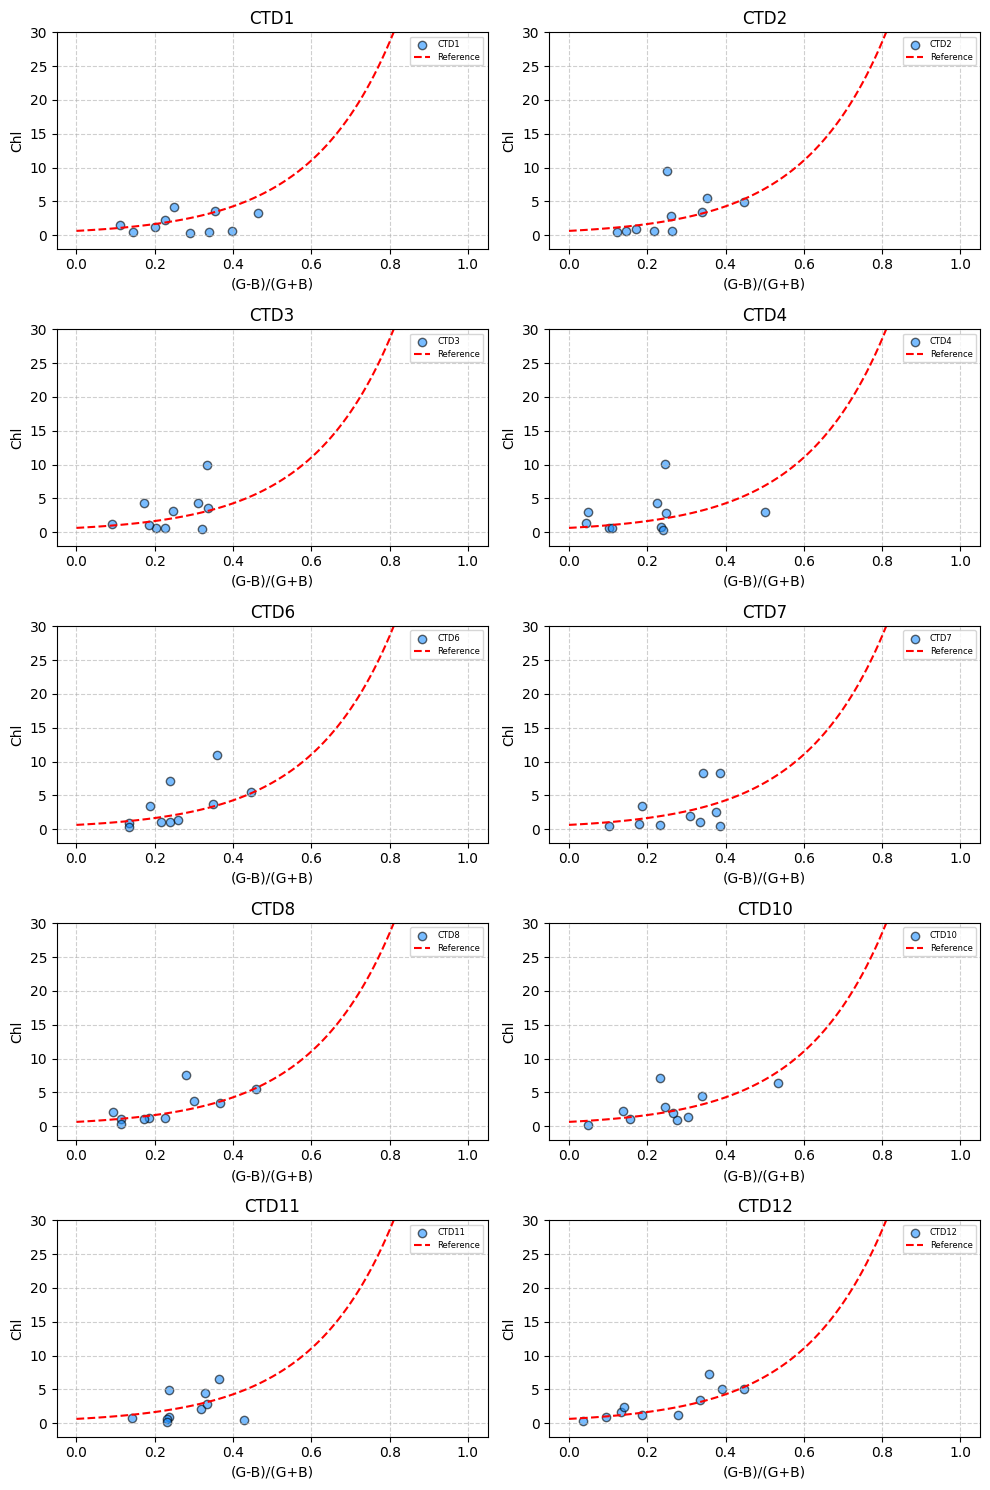

In [77]:
buoys = df["Buoy"].unique()

# Create subplots dynamically
fig, axes = plt.subplots(nrows=len(buoys)//2 + len(buoys)%2, ncols=2, figsize=(10, len(buoys)*1.5))
axes = axes.flatten()  # Flatten in case of multiple rows

# Reference curve for plotting
x_ref = np.linspace(0, 1, 101)
y_ref = 0.6386 * np.exp(4.7513 * x_ref)

for idx, buoy in enumerate(buoys):
    ax = axes[idx]
    
    # Filter data for the buoy
    df_buoy = df[df["Buoy"] == buoy]
    
    # Scatter plot
    ax.scatter(df_buoy["norm_dif_green_blue"], df_buoy["Chl"], color="dodgerblue", alpha=0.6, edgecolor="k", label=f"{buoy}")
    
    # Reference curve
    ax.plot(x_ref, y_ref, color="red", linestyle="--", label="Reference")
    
    ax.set_xlabel("(G-B)/(G+B)")
    ax.set_ylabel("Chl")
    ax.set_title(f"{buoy}")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_ylim(-2, 30)
    ax.legend(fontsize=6)

# If there are empty axes (because number of buoys is odd), hide them
for i in range(len(buoys), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

### 2. tfg

In [78]:
df = pd.read_csv("saved_files/df_boyas_tiffs_c2x_test.csv")
df = df.drop(columns=["Latitude", "Longitude"])
df = df.rename(columns={"Band_1" : "UltraBlue", "Band_2" : "Blue", "Band_3" : "Green", "Band_4" : "Red", "Band_5" : "NIR1", "Band_6" : "NIR2", "Band_7" : "NIR3"})
df['Date'] = pd.to_datetime(df['Date'])
dates = df["Date"].copy()
df = df.drop(columns=["Date"]) 

In [208]:
filter_dates = [
    "28/10/2016", "20/06/2018", "07/11/2018", "14/08/2019",
    "30/06/2017", "10/07/2018", "12/03/2019", "18/09/2019",
    "20/02/2018", "29/08/2018", "25/06/2019", "03/10/2019",
    "07/03/2018", "03/10/2018"
]

filter_dates_dt = pd.to_datetime(filter_dates, dayfirst=True)

# Filter the DataFrame
df = df[df["Date"].isin(filter_dates_dt)]

In [79]:
def norm_sum(band1, band2, band3):
    index = (band1 + band3)/(band1 + band2)
    return index

def add_index(data):
    df["norm_sum"] = norm_sum(data["Green"], data["Red"], data["NIR1"])
    df["Chl_pred"] = 124.94*norm_sum(data["Green"], data["Red"], data["NIR1"])-115.35
    
add_index(df)


In [80]:
rmse = np.sqrt(mean_squared_error(df["Chl"], df["Chl_pred"]))
print('RMSE: %.3f' % rmse)
r2 = r2_score(df["Chl"], df["Chl_pred"])
print('R squared: %.3f' % r2)
nrmse = rmse / np.mean(df["Chl"]) * 100
print(f"NRMSE: {nrmse:.1f}%")


RMSE: 3.377
R squared: -0.752
NRMSE: 122.7%


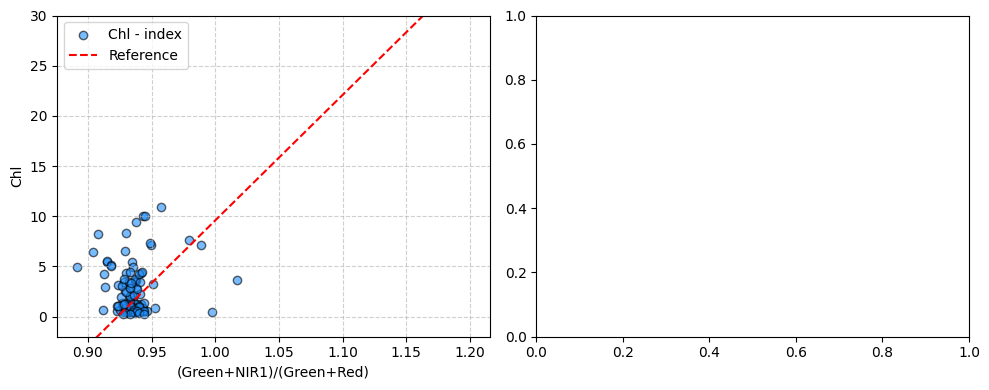

In [81]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

# Train plot
axes[0].scatter(df["norm_sum"], df["Chl"], color="dodgerblue", alpha=0.6, edgecolor="k", label="Chl - index")
x_ref = np.linspace(0.9, 1.2, 101)
y_ref = 124.94*x_ref-115.35
axes[0].plot(x_ref, y_ref, color="red", linestyle="--", label="Reference")
axes[0].set_xlabel("(Green+NIR1)/(Green+Red)")
axes[0].set_ylabel("Chl")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].set_ylim(-2,30)

plt.tight_layout()
plt.show()

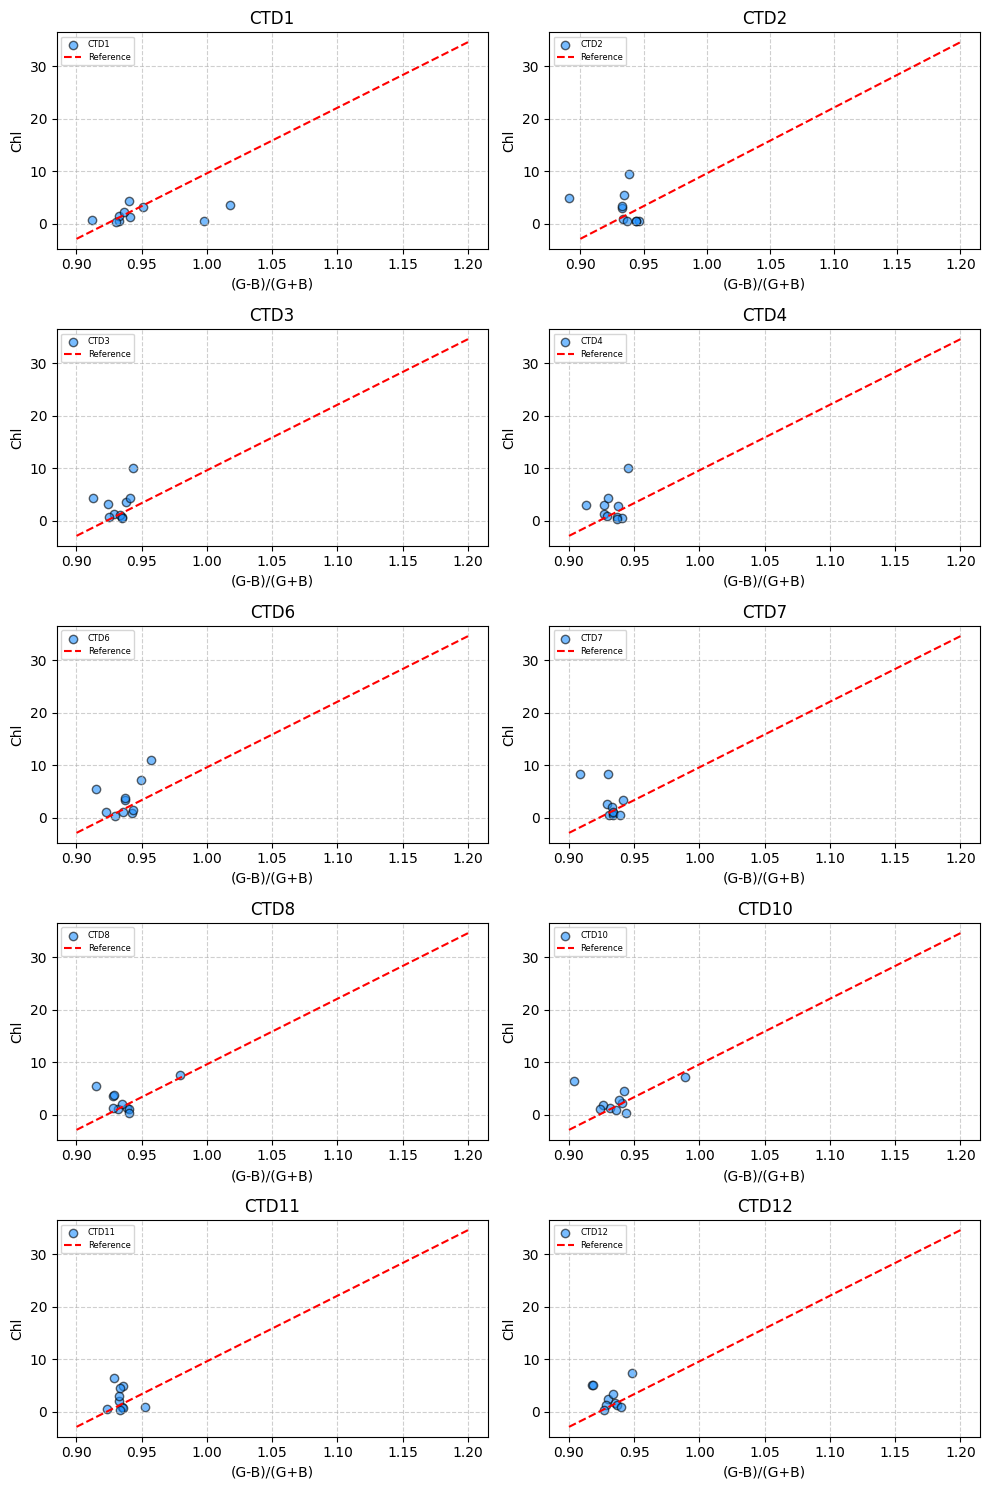

In [82]:
buoys = df["Buoy"].unique()

# Create subplots dynamically
fig, axes = plt.subplots(nrows=len(buoys)//2 + len(buoys)%2, ncols=2, figsize=(10, len(buoys)*1.5))
axes = axes.flatten()  # Flatten in case of multiple rows

# Reference curve for plotting
x_ref = np.linspace(0.9, 1.2, 101)
y_ref = 124.94*x_ref-115.35

for idx, buoy in enumerate(buoys):
    ax = axes[idx]
    
    # Filter data for the buoy
    df_buoy = df[df["Buoy"] == buoy]
    
    # Scatter plot
    ax.scatter(df_buoy["norm_sum"], df_buoy["Chl"], color="dodgerblue", alpha=0.6, edgecolor="k", label=f"{buoy}")
    
    # Reference curve
    ax.plot(x_ref, y_ref, color="red", linestyle="--", label="Reference")
    
    ax.set_xlabel("(G-B)/(G+B)")
    ax.set_ylabel("Chl")
    ax.set_title(f"{buoy}")
    ax.grid(True, linestyle="--", alpha=0.6)
    #ax.set_ylim(-2, 30)
    ax.legend(fontsize=6)

# If there are empty axes (because number of buoys is odd), hide them
for i in range(len(buoys), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [53]:
df

,Buoy,UltraBlue,Blue,Green,Red,NIR1,NIR2,NIR3,Band_8,Band_9,Band_10,Band_11,Band_12,Band_13,Band_14,Band_15,Chl,norm_sum,Chl_pred,Chl_fit
0,CTD1,0.001928,0.002420,0.004708,0.002355,0.005023,0.000918,0.000832,0.000323,0.001941,0.002402,0.004896,0.002966,0.003248,0.001205,-2.890000e-42,3.243742,1.377721,56.782457,5.622994
1,CTD2,0.003218,0.004708,0.009080,0.002519,0.002962,0.000576,0.000589,0.000226,0.003233,0.004583,0.009244,0.002745,0.002278,0.000685,-2.890000e-42,4.962618,1.038126,14.353475,3.380254
2,CTD3,0.006712,0.011739,0.019065,0.004275,0.002894,0.000671,0.000666,0.000262,0.006696,0.011694,0.019171,0.004405,0.002907,0.000684,-2.878000e-42,3.602579,0.940840,2.198497,2.737758
3,CTD4,0.009758,0.015124,0.024104,0.006764,0.005163,0.001212,0.001197,0.000470,0.009756,0.014988,0.024258,0.007039,0.004964,0.001241,-8.000000e-45,2.846045,0.948116,3.107634,2.785814
4,CTD6,0.011325,0.017116,0.027421,0.008611,0.006838,0.001683,0.001667,0.000660,0.011284,0.016943,0.027603,0.008844,0.006516,0.001710,-8.000000e-45,7.132293,0.950808,3.443904,2.803589
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,CTD7,0.040380,0.058227,0.068266,0.013929,0.008107,0.002057,0.001970,0.000791,0.040609,0.056176,0.068756,0.014061,0.008630,0.001881,-8.000000e-45,0.557045,0.929173,0.740909,2.660712
96,CTD8,0.015225,0.022530,0.023438,0.003139,0.002056,0.000520,0.000500,0.000193,0.015268,0.022492,0.023753,0.003121,0.002074,0.000535,-2.878000e-42,0.333898,0.959234,4.496683,2.859237
97,CTD10,0.006732,0.009988,0.012679,0.002026,0.001590,0.000352,0.000354,0.000134,0.006706,0.009893,0.012735,0.002073,0.001461,0.000376,-2.878000e-42,0.236828,0.970346,5.885042,2.932624
98,CTD11,0.011044,0.017356,0.022203,0.003993,0.002722,0.000648,0.000631,0.000247,0.011051,0.017340,0.022290,0.004116,0.002792,0.000677,-8.000000e-45,0.248682,0.951465,3.526033,2.807930


In [83]:
from sklearn.linear_model import LinearRegression

X = df[["norm_sum"]] 
y = df["Chl"]

model = LinearRegression().fit(X, y)
df["Chl_fit"] = model.predict(X)

r2 = r2_score(y, df["Chl_fit"])
rmse = np.sqrt(mean_squared_error(y, df["Chl_fit"]))
nrmse = rmse / np.mean(y) * 100
print('RMSE: %.3f' % rmse)
print('R squared: %.3f' % r2)
print(f"NRMSE: {nrmse:.1f}%")

RMSE: 2.546
R squared: 0.004
NRMSE: 92.5%
